
<br>
<font>
<div dir=ltr align=center>
<img src="https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png" width=150 height=150> <br>
<font color=0F5298 size=7>
Applied Data Science (25879) <br>
<font color=2565AE size=5>
Electrical Engineering Department <br>

<font color=3C99D size=5>
Computer Assignment 1 - Spring 2026<br>

<font color=696880 size=4>
Amitis Mirabedini - 402102562

# Exploratory Data Analysis (EDA)

In this section, I will explore the dataset, understand its structure, check for data quality issues, and perform initial cleaning and preprocessing.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# Styling for better visualization purposes
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

### Loading the Dataset


In [2]:
df = pd.read_csv('Automobile_data.csv')
#Quick check
# Sample rows
df.head()



,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [3]:
# Number of rows and columns
df.shape

(205, 26)

In [4]:
# Feature Names
df.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='object')

In [5]:
# data types and missing value hints
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

The dataset used in this assignment is Automobile_data.csv, which contains information about different cars and their physical, mechanical, and performance characteristics. It has 205 rows and 26 columns.

The columns include both:

Categorical variables such as make, fuel-type, aspiration, body-style, drive-wheels, engine-type, and fuel-system
Numerical variables such as wheel-base, length, width, curb-weight, engine-size, horsepower, city-mpg, highway-mpg, and price

## Data Cleaning Overview

In this section, I will check the dataset for:  
- Missing values   
- Duplicate rows 
- Invalid values    

Cleaning the data ensures that the analysis is accurate and that any models built later are reliable.  
Based on the columns and their types we will have our guesses on how we can make the data clean regrading each problem and then use an appropriate approach to do so.

First we replace ? with proper missing values so we can handle it

In [6]:
# Replace '?' with NaN
df = df.replace("?", np.nan)


Now we convert the numeric columns to numeric type

In [7]:
# Columns that should be numeric
numeric_cols = [
    "normalized-losses", "wheel-base", "length", "width", "height",
    "curb-weight", "engine-size", "bore", "stroke",
    "compression-ratio", "horsepower", "peak-rpm",
    "city-mpg", "highway-mpg", "price"
]

# Convert to numeric
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


After replacing ? and converting types, we need to identify how many missing values remain in each column.

In [8]:
# Missing values per column
missing_counts = df.isna().sum()
print(missing_counts)


symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64


We then use the median to fill missing numeric values. Median is preferred because it is robust to outliers.

In [9]:
# Fill missing numeric values with median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())


Then for the Categorical columns which may also contain missing values, we fill them by using the mode. Based on our observation above and by looking at the data we can see that num-of-doors which is written with strings like two or four in the data has missing values. Note that we will handle the problem of num-of-doors being written as strings and convert them to numbers later.

In [10]:
# Categorical columns
categorical_cols = [
    "make", "fuel-type", "aspiration", "num-of-doors", "body-style",
    "drive-wheels", "engine-location", "engine-type",
    "num-of-cylinders", "fuel-system"
]

# Fill missing categorical values with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


Removing the duplicate rows:

In [11]:
# Check duplicates
print("Number of duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()


Number of duplicate rows: 0


When checking for impossible or invalid values, we must note that some numeric variables should not contain impossible values such as negative numvers or 0 where it doesn't make sense.  
So we check the important and relevant numeric columns for invalid values and replace them with .NaN, then we use the same approach we used for missing values above and re-impute them if needed.

In [12]:
# Columns where negative values are not meaningful
cols_to_check = [
    "normalized-losses", "wheel-base", "length", "width", "height",
    "curb-weight", "engine-size", "bore", "stroke",
    "compression-ratio", "horsepower", "peak-rpm",
    "city-mpg", "highway-mpg", "price"
]

# Replace invalid negative values with NaN
for col in cols_to_check:
    df.loc[df[col] < 0, col] = np.nan

# Refill missing values after invalid-value correction
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())


Now we need to verify the cleaned dataset

In [13]:
print("Final shape:", df.shape)
print("\nRemaining missing values:")
print(df.isna().sum())

print("\nData types:")
print(df.dtypes)


Final shape: (205, 26)

Remaining missing values:
symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

Data types:
symboling              int64
normalized-losses    float64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width  

We can confirm now that there are no missing values left, and the data has been properly cleaned.  
The data didn't have duplicate rows becuase the input and output size of our dataset has not changed, however we implemented the algorithm just in case we were dealing with another kind of data.

# Preprocessing Overview  

Since the dataset used contains many categorical features, the next step is to convert them into numerical values so they can be used for correlation analysis, standardization, PCA,... later on.   

1. Convert num-of-cylinders ---> Integer
2. Convert num-of-doors ---> Integer
3. One-hot encode all remaining categorical columns  

### Why One-hot?
One-hot encoding is used because these variables don't have a natural orser, and one-hot encoding avoids introducing artificial relationships between categories. 



In [14]:
# Mapping dictionaries
cylinder_map = {
    "two": 2,
    "three": 3,
    "four": 4,
    "five": 5,
    "six": 6,
    "eight": 8,
    "twelve": 12
}

door_map = {
    "two": 2,
    "four": 4
}

df["num-of-cylinders"] = df["num-of-cylinders"].map(cylinder_map)
df["num-of-doors"] = df["num-of-doors"].map(door_map)


In [15]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Categorical columns to one-hot encode:")
print(categorical_cols)


Categorical columns to one-hot encode:
['make', 'fuel-type', 'aspiration', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'fuel-system']


In [16]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("New dataset shape:", df_encoded.shape)


New dataset shape: (205, 61)


In [17]:
df_encoded.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 61 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   symboling             205 non-null    int64  
 1   normalized-losses     205 non-null    float64
 2   num-of-doors          205 non-null    int64  
 3   wheel-base            205 non-null    float64
 4   length                205 non-null    float64
 5   width                 205 non-null    float64
 6   height                205 non-null    float64
 7   curb-weight           205 non-null    float64
 8   num-of-cylinders      205 non-null    int64  
 9   engine-size           205 non-null    float64
 10  bore                  205 non-null    float64
 11  stroke                205 non-null    float64
 12  compression-ratio     205 non-null    float64
 13  horsepower            205 non-null    float64
 14  peak-rpm              205 non-null    float64
 15  city-mpg              2

As we can see above by using one-hot-encoding for the categorical data we have increased the number of our data columns to 61.

# Standardization Overview  

After cleaning and encoding the dataset, feature scaling was applied using Standardization (Z‑score normalization). This method transforms each feature so that it has a mean of 0 and a standard deviation of 1. Standardization was performed using the StandardScaler function from the sklearn.preprocessing library. Two versions of the dataset were produced: one where only the predictor variables were standardized while keeping the target variable (price) unchanged, and another where all variables including price were standardized.  
The first version with price excluded as target is best for modeling and PCA.  
The second version which standardizes the price as well is best for comparison and full scaling goals.

In the code below price is treated as target variable

In [18]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# Create scaler
scaler = StandardScaler()

# Standardize features
X_scaled = scaler.fit_transform(X)

# Convert back to dataframe
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Final dataset
df_standardized_excl_price = pd.concat([X_scaled_df, y.reset_index(drop=True)], axis=1)


In the code below we have done the standardization including price

In [19]:
from sklearn.preprocessing import StandardScaler

scaler_all = StandardScaler()

# Standardize the entire dataset
all_scaled = scaler_all.fit_transform(df_encoded)

df_standardized_incl_price = pd.DataFrame(all_scaled, columns=df_encoded.columns)


To verify the results we must check the mean and standard deviation

In [20]:
df_standardized_excl_price.mean()


symboling            4.332578e-17
normalized-losses    1.819683e-16
num-of-doors        -6.932124e-17
wheel-base          -1.291108e-15
length               3.656696e-15
                         ...     
fuel-system_mfi      8.665155e-18
fuel-system_mpfi     0.000000e+00
fuel-system_spdi     8.665155e-18
fuel-system_spfi     8.665155e-18
price                1.315031e+04
Length: 61, dtype: float64

In [21]:
df_standardized_excl_price.std()


symboling               1.002448
normalized-losses       1.002448
num-of-doors            1.002448
wheel-base              1.002448
length                  1.002448
                        ...     
fuel-system_mfi         1.002448
fuel-system_mpfi        1.002448
fuel-system_spdi        1.002448
fuel-system_spfi        1.002448
price                7879.121326
Length: 61, dtype: float64

In [22]:
df_standardized_incl_price.mean()


symboling            4.332578e-17
normalized-losses    1.819683e-16
num-of-doors        -6.932124e-17
wheel-base          -1.291108e-15
length               3.656696e-15
                         ...     
fuel-system_idi     -1.733031e-17
fuel-system_mfi      8.665155e-18
fuel-system_mpfi     0.000000e+00
fuel-system_spdi     8.665155e-18
fuel-system_spfi     8.665155e-18
Length: 61, dtype: float64

In [23]:
df_standardized_incl_price.std()


symboling            1.002448
normalized-losses    1.002448
num-of-doors         1.002448
wheel-base           1.002448
length               1.002448
                       ...   
fuel-system_idi      1.002448
fuel-system_mfi      1.002448
fuel-system_mpfi     1.002448
fuel-system_spdi     1.002448
fuel-system_spfi     1.002448
Length: 61, dtype: float64

As we can see above, the results confirm that the standardization has been done accurately.

In [24]:
df_standardized_excl_price.head()

,symboling,normalized-losses,num-of-doors,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,...,engine-type_ohcv,engine-type_rotor,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi,price
0,1.743470,-0.176503,-1.141653,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,-0.352887,0.074449,...,-0.260208,-0.141069,-0.689072,-0.121867,-0.328798,-0.070014,1.08667,-0.214286,-0.070014,13495.0
1,1.743470,-0.176503,-1.141653,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,-0.352887,0.074449,...,-0.260208,-0.141069,-0.689072,-0.121867,-0.328798,-0.070014,1.08667,-0.214286,-0.070014,16500.0
2,0.133509,-0.176503,-1.141653,-0.708596,-0.231513,-0.190566,-0.543527,0.514882,1.502032,0.604046,...,3.843076,-0.141069,-0.689072,-0.121867,-0.328798,-0.070014,1.08667,-0.214286,-0.070014,16500.0
3,0.938490,1.367901,0.875923,0.173698,0.207256,0.136542,0.235942,-0.420797,-0.352887,-0.431076,...,-0.260208,-0.141069,-0.689072,-0.121867,-0.328798,-0.070014,1.08667,-0.214286,-0.070014,13950.0
4,0.938490,1.367901,0.875923,0.107110,0.207256,0.230001,0.235942,0.516807,0.574572,0.218885,...,-0.260208,-0.141069,-0.689072,-0.121867,-0.328798,-0.070014,1.08667,-0.214286,-0.070014,17450.0


In [25]:
df_standardized_incl_price.head()

,symboling,normalized-losses,num-of-doors,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,...,engine-type_ohcf,engine-type_ohcv,engine-type_rotor,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
0,1.743470,-0.176503,-1.141653,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,-0.352887,0.074449,...,-0.280976,-0.260208,-0.141069,-0.689072,-0.121867,-0.328798,-0.070014,1.08667,-0.214286,-0.070014
1,1.743470,-0.176503,-1.141653,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,-0.352887,0.074449,...,-0.280976,-0.260208,-0.141069,-0.689072,-0.121867,-0.328798,-0.070014,1.08667,-0.214286,-0.070014
2,0.133509,-0.176503,-1.141653,-0.708596,-0.231513,-0.190566,-0.543527,0.514882,1.502032,0.604046,...,-0.280976,3.843076,-0.141069,-0.689072,-0.121867,-0.328798,-0.070014,1.08667,-0.214286,-0.070014
3,0.938490,1.367901,0.875923,0.173698,0.207256,0.136542,0.235942,-0.420797,-0.352887,-0.431076,...,-0.280976,-0.260208,-0.141069,-0.689072,-0.121867,-0.328798,-0.070014,1.08667,-0.214286,-0.070014
4,0.938490,1.367901,0.875923,0.107110,0.207256,0.230001,0.235942,0.516807,0.574572,0.218885,...,-0.280976,-0.260208,-0.141069,-0.689072,-0.121867,-0.328798,-0.070014,1.08667,-0.214286,-0.070014


# Data Visualization

In this section, I'll be visualizing the data in a meaningfull way so we can understand the data better.

**Important note** : For data visaulization we use the cleaned version of our dataset before applying any kind of preprocessing like one-hot encoding and standardization.  
The preprocessed dataset is going to be used in the next part where we are dealing with features and modeling. 

### 1. Pie Charts and Box Plots

Pie charts are best for showing proportions of categorical data. Fuel type has few categories(gas/diesel), making it ideal. 

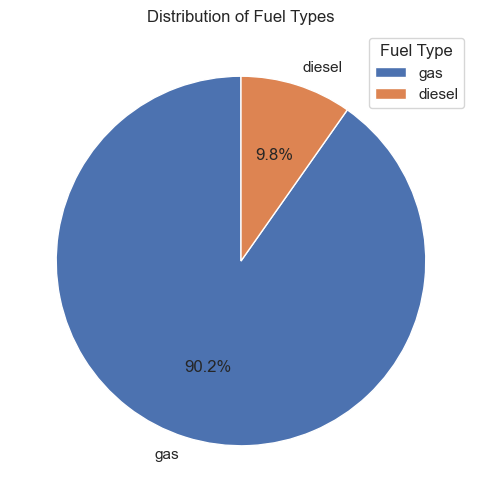

In [26]:
import matplotlib.pyplot as plt
df_cleaned = df.copy()

fuel_counts = df_cleaned['fuel-type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(fuel_counts,
        labels=fuel_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title('Distribution of Fuel Types')
plt.legend(title="Fuel Type")
plt.show()


As we can see above gas is the more common fuel type in our dataset's automobiles. We must keep our eyes on this column as it is imbalanced for later investigation in modeling and apply necessary changes and techniques to make it balanced if needed.

**Box Plots** show Median, Quartiles, Outliers and Spread of numeric variable across categories which is perfect for comparing price distribution by body style.  


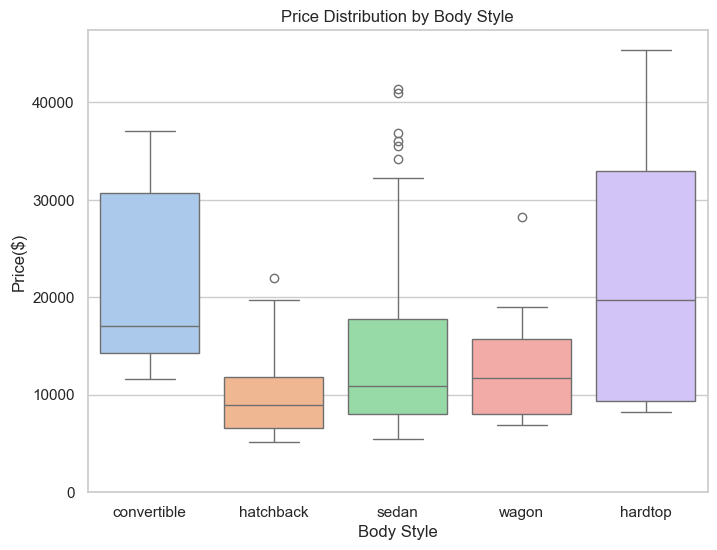

In [27]:
import seaborn as sns

palette = "pastel"
plt.figure(figsize=(8,6))
sns.boxplot(x='body-style', y='price', data=df_cleaned,hue = "body-style", palette=palette, legend = False)

plt.title('Price Distribution by Body Style')
plt.xlabel('Body Style')
plt.ylabel('Price($)')
plt.ylim(0, df_cleaned['price'].max() + 2000)

plt.show()


- Convertibles and hardtops have the highest median and widest price ranges, suggesting these models tend to be premium vehicles (possibly luxury/sport).
- Hatchbacks consistently have the lowest prices and the least variability; they are affordable and standardized.
- Sedans are mid-range but show the most outliers, indicating some sedans are far more expensive than others (possibly high-end variants).
- Wagons are priced between hatchbacks and convertibles, with moderate variability.
- The wide range and outliers in hardtop and sedan indicate these segments include both standard and premium models.

### 2. Line Charts Multi-Line Charts  

**Line Charts** emphasize trend in continuous data.  

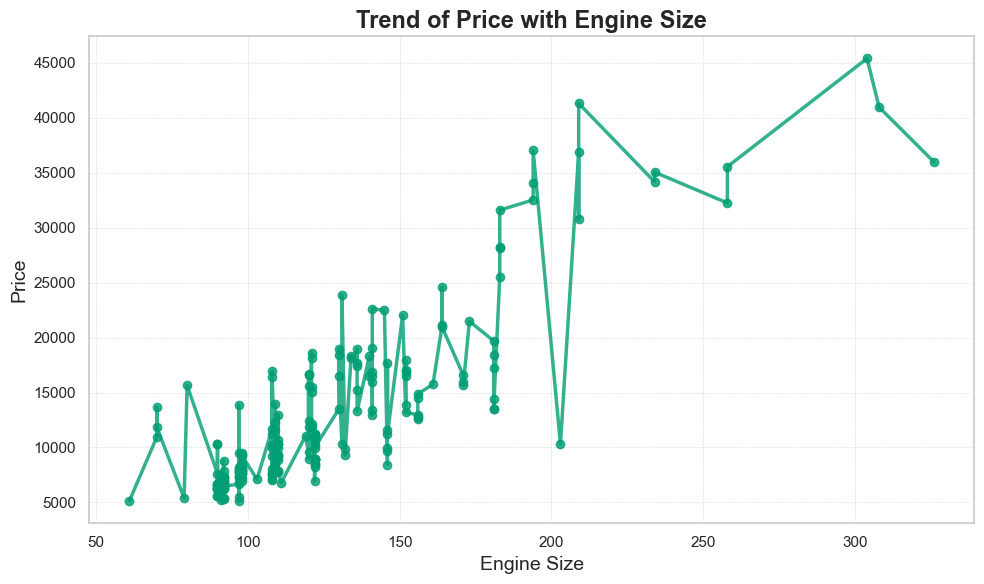

In [28]:
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Sort data to avoid lines jumping back and forth
sorted_data = df_cleaned.sort_values("engine-size")

plt.plot(sorted_data["engine-size"], sorted_data["price"], 
         marker='o', 
         color="#009e73", 
         linewidth=2.5, 
         alpha=0.8)

plt.title('Trend of Price with Engine Size', fontsize=17, fontweight="bold")
plt.xlabel('Engine Size', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.show()


We can observe that Multiple prices exist for the same engine size so the line jumps up and down widely. The trend is not so smooth and linear.

**Multi-Line Chart** 
Used to compare multiple numerical trends on same graph.  


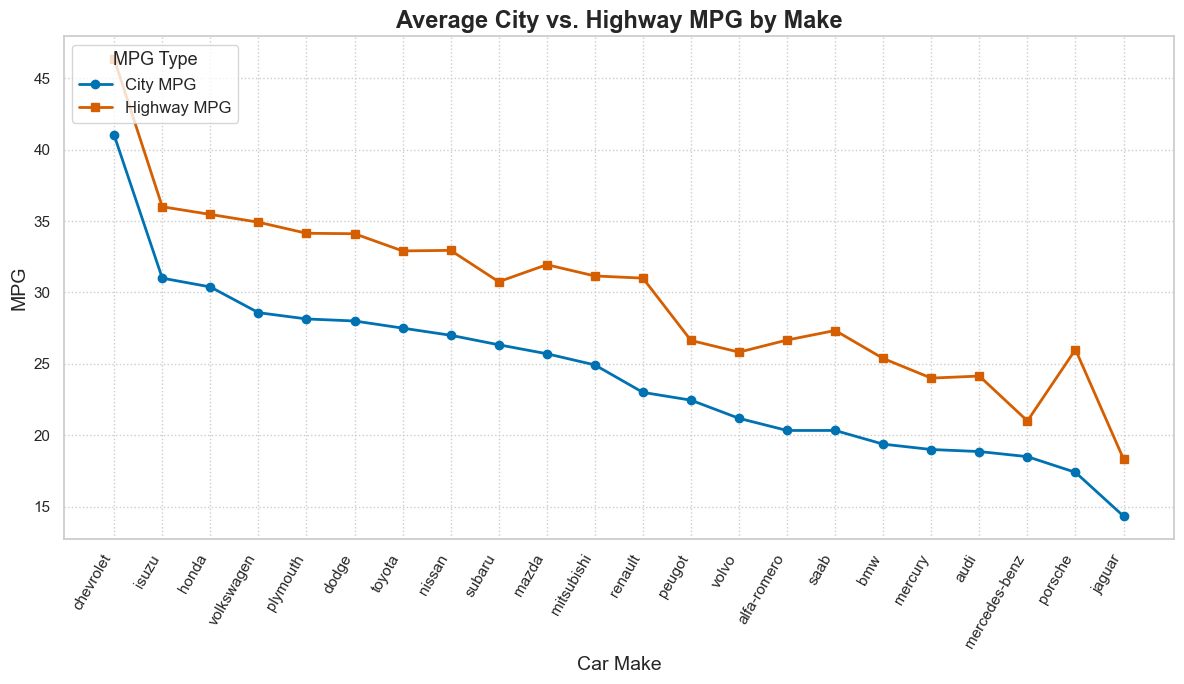

In [29]:
plt.figure(figsize=(12, 7))
sns.set(style="whitegrid")

# Prepare data
avg_mpg = df_cleaned.groupby('make')[['city-mpg', 'highway-mpg']].mean().sort_values('city-mpg', ascending=False)

plt.plot(avg_mpg.index, avg_mpg['city-mpg'], marker='o', color='#0072b2', label='City MPG', linewidth=2)
plt.plot(avg_mpg.index, avg_mpg['highway-mpg'], marker='s', color='#d55e00', label='Highway MPG', linewidth=2)

plt.title('Average City vs. Highway MPG by Make', fontsize=17, fontweight='bold')
plt.xlabel('Car Make', fontsize=14)
plt.ylabel('MPG', fontsize=14)
plt.xticks(rotation=60, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="MPG Type", fontsize=12, title_fontsize=13, loc='upper left')
plt.grid(True, which='major', linestyle=':', linewidth=1)
plt.tight_layout()
plt.show()


Here we can see that Highway MPG (Miles Per Gallon) is always higher than City MPG. We can also see that some brands such as porche or jaguar are the least fuel effiecient and chevrolet is the best in that matter.

### 3. Bar Charts (Grouped and Stacked)

Bar Charts are best for comparing means across categories.

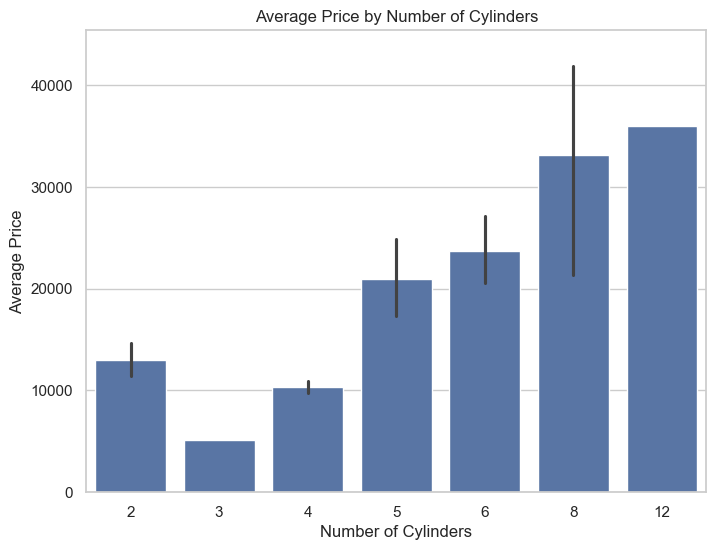

In [30]:
plt.figure(figsize=(8,6))
sns.barplot(x='num-of-cylinders',
            y='price',
            data=df_cleaned,
            estimator='mean')

plt.title('Average Price by Number of Cylinders')
plt.xlabel('Number of Cylinders')
plt.ylabel('Average Price')
plt.ylim(0, df_cleaned['price'].max())

plt.show()


We can observe that when the number of cylinders pass 4 there is an increasing trend between the average price of the automobile and the number of cylinders and the prices go higer.  
8-cylinder cars have wide range of prices and fewer observations thats why the black line which show the uncertainty/spread of the prices is longer on that group. The black lines show the variability of the data specifically the 95% confidence interval arounf the mean.  
While a positive correlation generally exists between the number of cylinders and price, 2-cylinder vehicles in this dataset show a higher average price than 3-cylinder vehicles. This is an outlier caused by the specific models represented: the 2-cylinder entries consist of high-performance Mazda rotary-engine sports cars, whereas the 3-cylinder entries are budget-focused economy hatchbacks designed for low cost and high fuel efficiency.

**This is perfect example of why domain knowledge here is importnat as we also discussed it in the class. If we just look at the numbers we might think the data is "wrong". But by looking at the specific car models, we realize that the data is actually reflecting the real-world market then.**

**Stacked Bar Chart**
Shows relationship between two categorical variables.

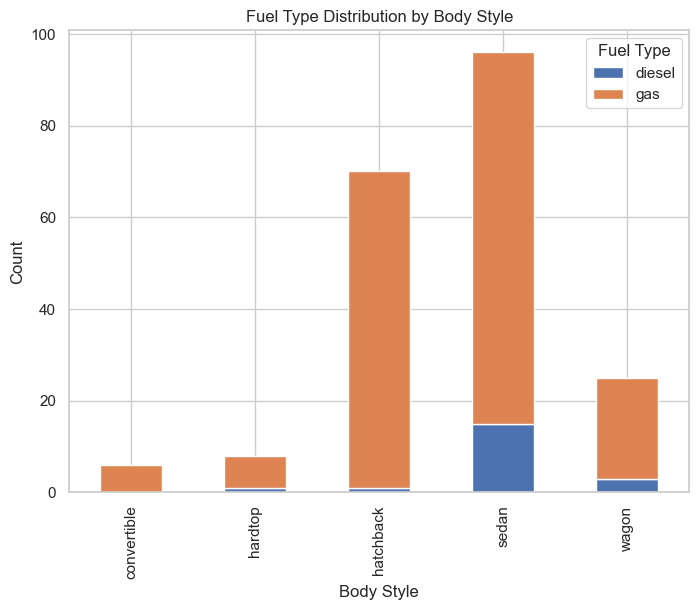

In [31]:
cross_tab = pd.crosstab(df_cleaned['body-style'],
                        df_cleaned['fuel-type'])

cross_tab.plot(kind='bar',
               stacked=True,
               figsize=(8,6))

plt.title('Fuel Type Distribution by Body Style')
plt.xlabel('Body Style')
plt.ylabel('Count')
plt.legend(title='Fuel Type')

plt.show()


As we can see, across all the body styles, gas-powered cars vastly outnumber diesel cars. This reflects the real-world market of the datset's ear, where gasoline engines were far more common than diesel in passenger vehicles.  
Sedans have the highest total count of vehicles and they also contain the largest number of diesel cars compared to other body styles.  
This suggests sedans were the primary segment where diesel engines were offered.  
Hatchbacks are numerous but almost entirely gas-powered.  
Diesel engines appear mostly in **Sedans and Wagons** and body styles such as **Convertibles and Hardtops** are almost exclusively gasoline-powered.

### 4. Scatter Plots and Bubble Charts

**Scatter Plots** are best for examining correlation between two numerical values.

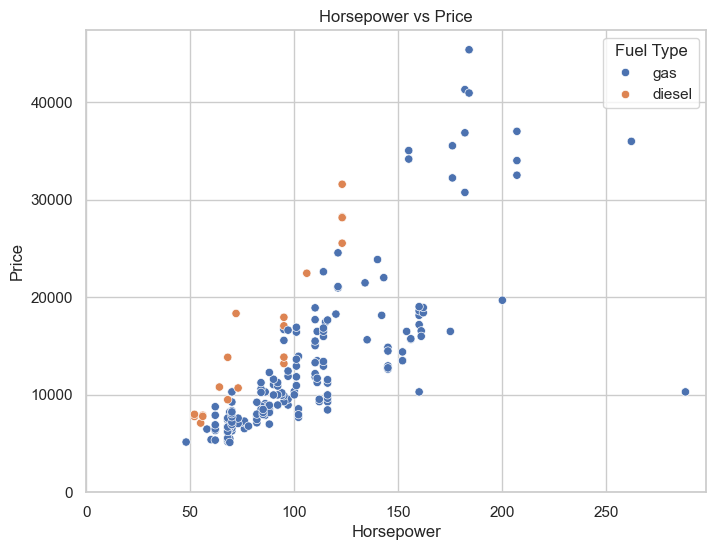

In [32]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='horsepower',
                y='price',
                hue='fuel-type',
                data=df_cleaned)

plt.title('Horsepower vs Price')
plt.xlabel('Horsepower')
plt.ylabel('Price')
plt.xlim(0, df_cleaned['horsepower'].max()+10)
plt.ylim(0, df_cleaned['price'].max()+2000)
plt.legend(title='Fuel Type')

plt.show()


As Horsepower increases, price increases. Low-power cars(50-90hp) cluster at lower prices, while high-power(150+ hp) cars are mostly in the high-price region.  
Diesel points sit mostly in the low-mid horsepower range with mid-range prices. 

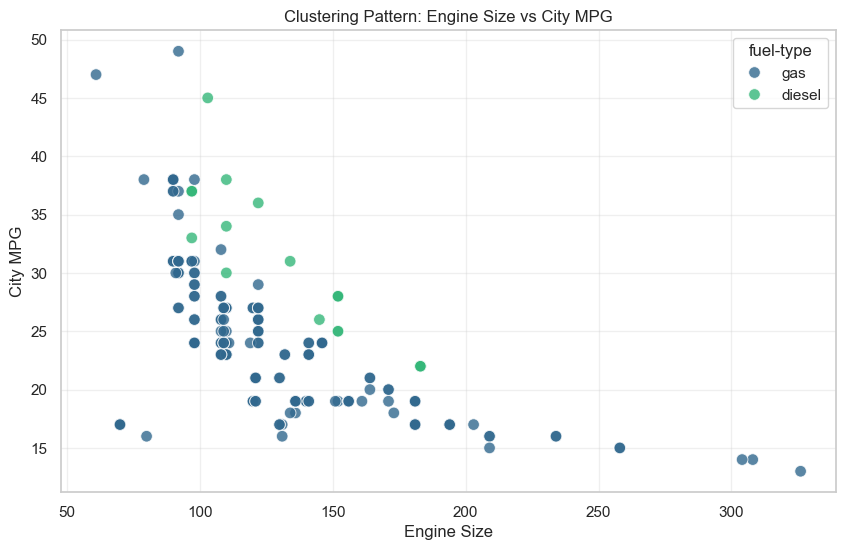

In [33]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_cleaned,
    x="engine-size",
    y="city-mpg",
    hue="fuel-type",
    palette="viridis",
    s=70,
    alpha=0.8
)
plt.title("Clustering Pattern: Engine Size vs City MPG")
plt.xlabel("Engine Size")
plt.ylabel("City MPG")
plt.grid(True, alpha=0.3)
plt.show()


As engine size increases, city MPG decreases. Small engines achieve high MPGH(30-50) while large engines have low MPG(13-18).  
Diesel points are mostly in the small-medium engine size range but often with relatively higher MPG than similar-sized gas cars.  
This visually supports the idea that diesel is more fuel-efficient at a given engine size.

**Bubble Charts** Adds a third dimenion like Price here
Engine Size vs Horsepower (Size = Price)

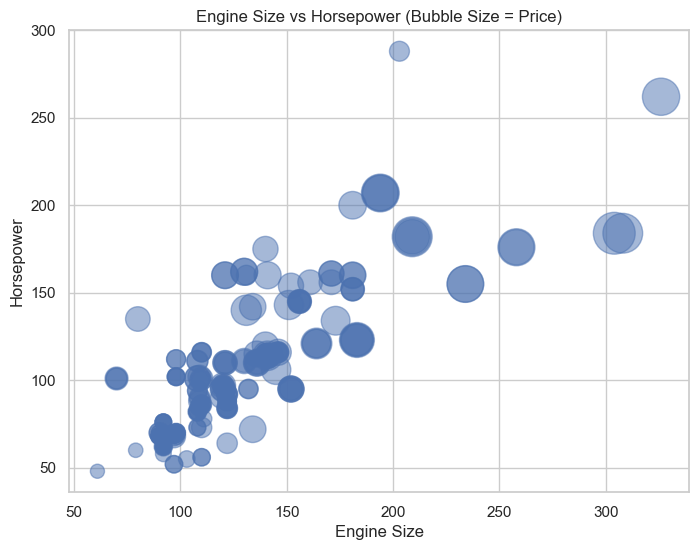

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(df_cleaned['engine-size'],
            df_cleaned['horsepower'],
            s=df_cleaned['price']/50,
            alpha=0.5)

plt.title('Engine Size vs Horsepower (Bubble Size = Price)')
plt.xlabel('Engine Size')
plt.ylabel('Horsepower')


plt.show()


Engine size strongly affects price as bigger bubbles are more expensive cars and also we can see that the larger the engine the higher the horsepower.

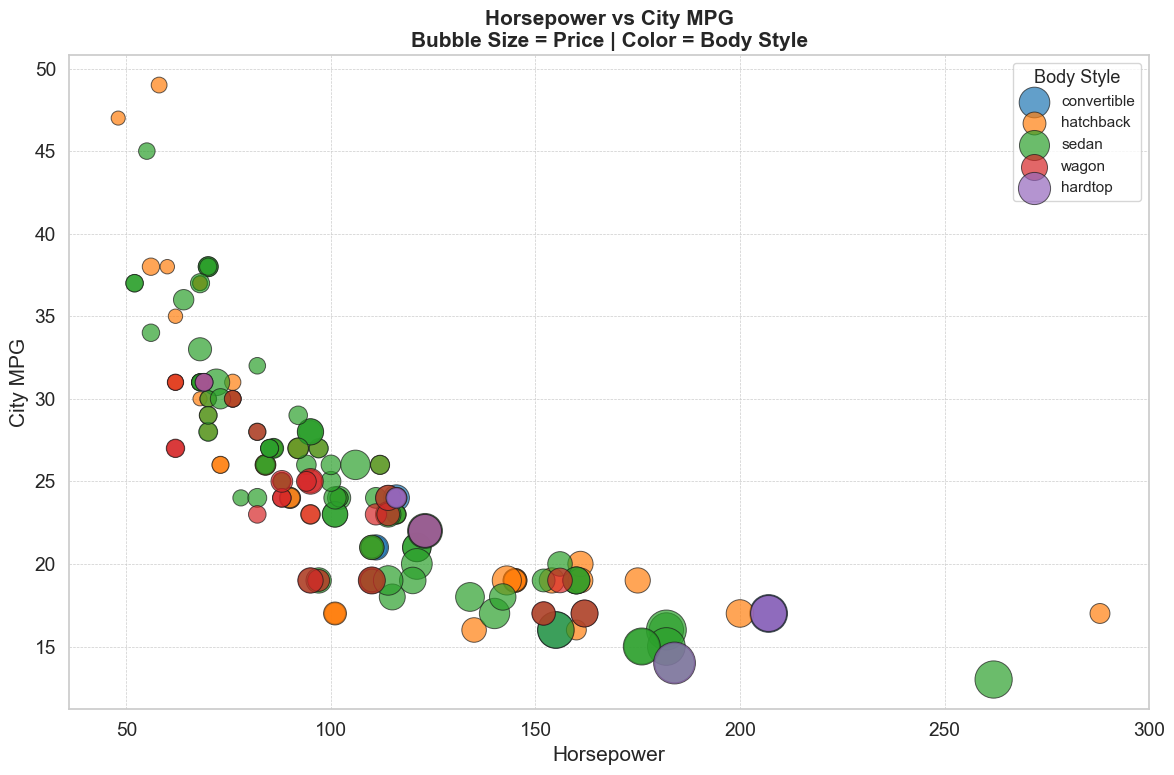

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.set(style="whitegrid", font_scale=1.25)

# Create explicit palette mapping
unique_styles = df_cleaned["body-style"].unique()
palette = dict(zip(unique_styles, sns.color_palette("tab10", len(unique_styles))))

# Plot with consistent colors
for style in unique_styles:
    subset = df_cleaned[df_cleaned["body-style"] == style]
    plt.scatter(
        subset["horsepower"],
        subset["city-mpg"],
        s=subset["price"] / 50,
        color=palette[style],
        alpha=0.7,
        edgecolor='k',
        linewidth=0.7,
        label=style
    )

plt.xlabel("Horsepower")
plt.ylabel("City MPG")
plt.title("Horsepower vs City MPG\nBubble Size = Price | Color = Body Style", weight="bold")
plt.legend(title="Body Style", fontsize=11, title_fontsize=13, frameon=True)
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


Each body style forms recognizable clusters:

Hatchbacks (orange):

Mostly low horsepower and high city MPG.
Small to medium bubble sizes → cheap and fuel-efficient.

Sedans (green):  
Widely spread across horsepower and MPG.
Represent the mainstream market, balancing performance, efficiency, and price.  

Wagons (red):  
Cluster in mid horsepower and mid MPG.
Moderate bubble sizes → practical, mid-priced family cars.

Convertibles (blue) & Hardtops (purple):  
Appear mostly at higher horsepower with lower MPG.
Larger bubbles → premium and performance-oriented vehicles.

### 5. Charts Showing undertainty (Error Bars)

These show variability and reliability of mean values.

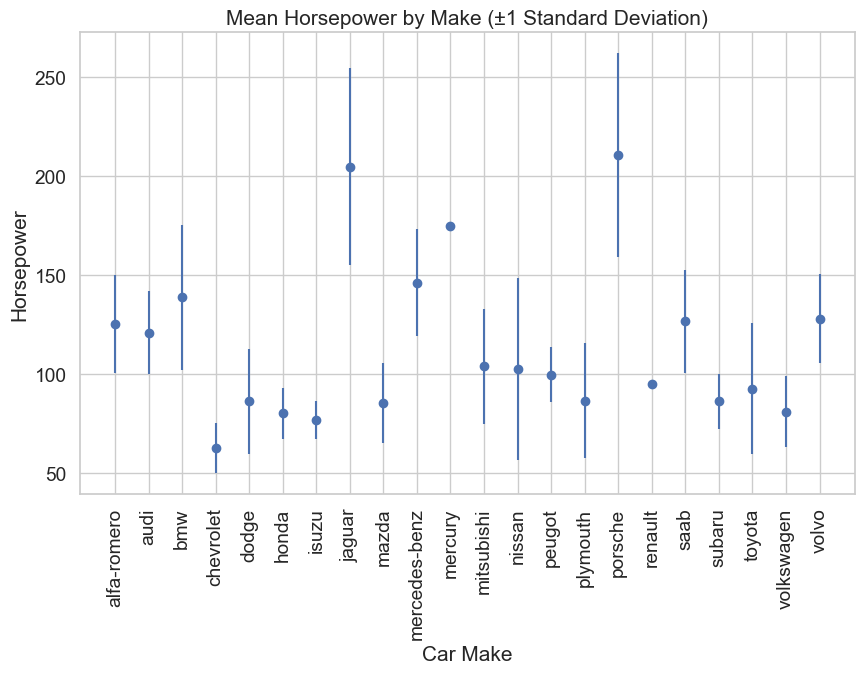

In [36]:
hp_stats = df_cleaned.groupby('make')['horsepower'].agg(['mean','std'])

plt.figure(figsize=(10,6))

plt.errorbar(hp_stats.index,
             hp_stats['mean'],
             yerr=hp_stats['std'],
             fmt='o')

plt.xticks(rotation=90)
plt.title('Mean Horsepower by Make (±1 Standard Deviation)')
plt.xlabel('Car Make')
plt.ylabel('Horsepower')

plt.show()


Large error bars indicate high variability like porche and jaguar while some brands like honda or isuzu or renault have almost consistent engine preformance.

### 6. Interactive Charts

**Interactive Scatter**

In [37]:
import plotly.express as px

fig = px.scatter(df_cleaned,
                 x='horsepower',
                 y='price',
                 color='fuel-type',
                 size='engine-size',
                 hover_data=['make','body-style'],
                 title='Interactive: Horsepower vs Price')

fig.update_layout(
    xaxis_title='Horsepower',
    yaxis_title='Price'
)

fig.show()


**Interactive Bar Chart**

In [38]:
avg_price = df_cleaned.groupby('make')['price'].mean().reset_index()

fig = px.bar(avg_price,
             x='make',
             y='price',
             color='price',
             title='Interactive: Average Price by Make')

fig.update_layout(
    xaxis_title='Car Make',
    yaxis_title='Average Price'
)

fig.show()


# Feature Engineering Overview
Feature engineering is the process of creating new variables from existing data to improve model performance and reveal hidden patterns. In this section, we generate new features using mathematical transformations, ratios, binning techniques, and aggregation methods. Additionally, we apply feature selection using Mutual Information and dimensionality reduction using Principal Component Analysis (PCA) to improve the dataset’s usefulness for machine learning models.

**Important Note**  
Feature Engineering should ALWAYS be done before standardization.  
So we still use df_cleaned

**Important Note**  
As price is out target variable in the next steps, we must not create any features containing price somehow in the feature engineering step.

## 1. Creating New Features

**1.1 Ratio Features**  

Ratio-based features help capture relationships between variables that are not obvious when examining them individually. For example, dividing horsepower by engine size can provide insight into engine efficiency or performance intensity.


In [39]:
df_fe = df_cleaned.copy()

# Power relative to weight
df_fe["hp_per_weight"] = df_fe["horsepower"] / df_fe["curb-weight"]

# Engine efficiency proxy
df_fe["hp_per_engine_size"] = df_fe["horsepower"] / df_fe["engine-size"]

# Engine density
df_fe["engine_size_per_weight"] = df_fe["engine-size"] / df_fe["curb-weight"]

# Bore to stroke ratio
df_fe["bore_stroke_ratio"] = df_fe["bore"] / df_fe["stroke"]

# Compression per engine size
df_fe["compression_per_engine"] = df_fe["compression-ratio"] / df_fe["engine-size"]


df_fe.head()


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,horsepower,peak-rpm,city-mpg,highway-mpg,price,hp_per_weight,hp_per_engine_size,engine_size_per_weight,bore_stroke_ratio,compression_per_engine
0,3,115.0,alfa-romero,gas,std,2,convertible,rwd,front,88.6,...,111.0,5000.0,21.0,27.0,13495.0,0.043564,0.853846,0.051020,1.294776,0.069231
1,3,115.0,alfa-romero,gas,std,2,convertible,rwd,front,88.6,...,111.0,5000.0,21.0,27.0,16500.0,0.043564,0.853846,0.051020,1.294776,0.069231
2,1,115.0,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,...,154.0,5000.0,19.0,26.0,16500.0,0.054552,1.013158,0.053843,0.772334,0.059211
3,2,164.0,audi,gas,std,4,sedan,fwd,front,99.8,...,102.0,5500.0,24.0,30.0,13950.0,0.043646,0.935780,0.046641,0.938235,0.091743
4,2,164.0,audi,gas,std,4,sedan,4wd,front,99.4,...,115.0,5500.0,18.0,22.0,17450.0,0.040722,0.845588,0.048159,0.938235,0.058824


**1.2 Binning**  

In this stage, several continuous variables were converted into categorical groups using binning techniques. This transformation simplifies complex numerical relationships and allows machine learning models to capture non‑linear patterns more effectively. Features such as price, engine size, vehicle weight, horsepower, and fuel efficiency were categorized into meaningful groups representing market segments, performance levels, and efficiency classes.


In [40]:
df_fe["hp_level"] = pd.cut(
    df_fe["horsepower"],
    bins=4,
    labels=["Low Power", "Moderate Power", "High Power", "Very High Power"]
)



df_fe["engine_size_category"] = pd.cut(
    df_fe["engine-size"],
    bins=3,
    labels=["Small Engine", "Medium Engine", "Large Engine"]
)

df_fe["weight_category"] = pd.cut(
    df_fe["curb-weight"],
    bins=3,
    labels=["Light", "Medium", "Heavy"]
)

df_fe["mpg_category"] = pd.cut(
    df_fe["city-mpg"],
    bins=3,
    labels=["Low Efficiency", "Medium Efficiency", "High Efficiency"]
)




df_fe.head()


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,price,hp_per_weight,hp_per_engine_size,engine_size_per_weight,bore_stroke_ratio,compression_per_engine,hp_level,engine_size_category,weight_category,mpg_category
0,3,115.0,alfa-romero,gas,std,2,convertible,rwd,front,88.6,...,13495.0,0.043564,0.853846,0.051020,1.294776,0.069231,Moderate Power,Small Engine,Medium,Low Efficiency
1,3,115.0,alfa-romero,gas,std,2,convertible,rwd,front,88.6,...,16500.0,0.043564,0.853846,0.051020,1.294776,0.069231,Moderate Power,Small Engine,Medium,Low Efficiency
2,1,115.0,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,...,16500.0,0.054552,1.013158,0.053843,0.772334,0.059211,Moderate Power,Medium Engine,Medium,Low Efficiency
3,2,164.0,audi,gas,std,4,sedan,fwd,front,99.8,...,13950.0,0.043646,0.935780,0.046641,0.938235,0.091743,Low Power,Small Engine,Light,Low Efficiency
4,2,164.0,audi,gas,std,4,sedan,4wd,front,99.4,...,17450.0,0.040722,0.845588,0.048159,0.938235,0.058824,Moderate Power,Small Engine,Medium,Low Efficiency


**1.3 Mathematical Transformations**  

Mathematical transformations such as logarithms help reduce skewness in variables like price, which often have long tails due to expensive vehicles.

In [41]:
import numpy as np

# Log transformations
df_fe["log_engine_size"] = np.log1p(df_fe["engine-size"])
df_fe["log_horsepower"] = np.log1p(df_fe["horsepower"])
df_fe["log_weight"] = np.log1p(df_fe["curb-weight"])

# Square transformations
df_fe["horsepower_squared"] = df_fe["horsepower"] ** 2
df_fe["engine_size_squared"] = df_fe["engine-size"] ** 2

# Square root transformations
df_fe["sqrt_weight"] = np.sqrt(df_fe["curb-weight"])
df_fe["sqrt_engine_size"] = np.sqrt(df_fe["engine-size"])


**1.4 Feature Combinations**  

Feature combinations capture interactions between variables that might influence the target variable.

In [42]:
# Power-weight interaction
df_fe["hp_weight_interaction"] = df_fe["horsepower"] * df_fe["curb-weight"]

# Engine size and horsepower interaction
df_fe["engine_hp_interaction"] = df_fe["engine-size"] * df_fe["horsepower"]

# Engine size and compression interaction
df_fe["engine_compression_interaction"] = df_fe["engine-size"] * df_fe["compression-ratio"]

# Length and width interaction (vehicle size indicator)
df_fe["car_size_area"] = df_fe["length"] * df_fe["width"]

# Weight and engine interaction
df_fe["engine_weight_interaction"] = df_fe["engine-size"] * df_fe["curb-weight"]


**1.5 Counts / Aggregation Statistics**  

Aggregation features summarize information across groups. For example, calculating the average price for each car make provides insight into brand positioning.

In [43]:
# Number of cars per manufacturer
df_fe["count_per_make"] = df_fe.groupby("make")["make"].transform("count")

# Average horsepower per body style
df_fe["avg_hp_by_body_style"] = df_fe.groupby("body-style")["horsepower"].transform("mean")

# Average engine size per make
df_fe["avg_engine_size_by_make"] = df_fe.groupby("make")["engine-size"].transform("mean")

# Average weight per body style
df_fe["avg_weight_by_body_style"] = df_fe.groupby("body-style")["curb-weight"].transform("mean")

# Average compression ratio by engine type
df_fe["avg_compression_by_engine_type"] = df_fe.groupby("engine-type")["compression-ratio"].transform("mean")


In [44]:
df_fe.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,hp_weight_interaction,engine_hp_interaction,engine_compression_interaction,car_size_area,engine_weight_interaction,count_per_make,avg_hp_by_body_style,avg_engine_size_by_make,avg_weight_by_body_style,avg_compression_by_engine_type
0,3,115.0,alfa-romero,gas,std,2,convertible,rwd,front,88.6,...,282828.0,14430.0,1170.0,10820.08,331240.0,3,131.666667,137.333333,2801.666667,9.000000
1,3,115.0,alfa-romero,gas,std,2,convertible,rwd,front,88.6,...,282828.0,14430.0,1170.0,10820.08,331240.0,3,131.666667,137.333333,2801.666667,9.000000
2,1,115.0,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,...,434742.0,23408.0,1368.0,11213.60,429096.0,3,101.242857,137.333333,2348.185714,8.823077
3,2,164.0,audi,gas,std,4,sedan,fwd,front,99.8,...,238374.0,11118.0,1090.0,11690.92,254733.0,7,103.104167,130.714286,2610.593750,10.210270
4,2,164.0,audi,gas,std,4,sedan,4wd,front,99.4,...,324760.0,15640.0,1088.0,11726.24,384064.0,7,103.104167,130.714286,2610.593750,10.210270


## 2.Feature Selection Using Mutual Information   
Mutual Information measures the dependency between features and the target variable. Features with higher MI scores provide more information about the target and are therefore more useful for prediction.

**Important Note**  
Here we are going to standardize our data again because we have added columns and then procees with Selection.

ONE-HOT ENCODING AND STANDARDIZING THE DATASET AGAIN

In [45]:

categorical_cols = df_fe.select_dtypes(include=['object','category']).columns
numerical_cols = df_fe.select_dtypes(include=np.number).columns 

# Perform One-Hot Encoding
df_encoded = pd.get_dummies(df_fe, columns=categorical_cols, drop_first=True)


In [46]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 92 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   symboling                           205 non-null    int64  
 1   normalized-losses                   205 non-null    float64
 2   num-of-doors                        205 non-null    int64  
 3   wheel-base                          205 non-null    float64
 4   length                              205 non-null    float64
 5   width                               205 non-null    float64
 6   height                              205 non-null    float64
 7   curb-weight                         205 non-null    float64
 8   num-of-cylinders                    205 non-null    int64  
 9   engine-size                         205 non-null    float64
 10  bore                                205 non-null    float64
 11  stroke                              205 non-n

In [47]:
# 'price' is the target variable and it's NOT standardized yet
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]


In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to a DataFrame to keep column names for later use (e.g., MI plots)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_df.head()


,symboling,normalized-losses,num-of-doors,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,...,fuel-system_spfi,hp_level_Moderate Power,hp_level_High Power,hp_level_Very High Power,engine_size_category_Medium Engine,engine_size_category_Large Engine,weight_category_Medium,weight_category_Heavy,mpg_category_Medium Efficiency,mpg_category_High Efficiency
0,1.743470,-0.176503,-1.141653,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,-0.352887,0.074449,...,-0.070014,1.451227,-0.249351,-0.099258,-0.484706,-0.158114,1.055179,-0.355491,-0.82482,-0.226455
1,1.743470,-0.176503,-1.141653,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,-0.352887,0.074449,...,-0.070014,1.451227,-0.249351,-0.099258,-0.484706,-0.158114,1.055179,-0.355491,-0.82482,-0.226455
2,0.133509,-0.176503,-1.141653,-0.708596,-0.231513,-0.190566,-0.543527,0.514882,1.502032,0.604046,...,-0.070014,1.451227,-0.249351,-0.099258,2.063107,-0.158114,1.055179,-0.355491,-0.82482,-0.226455
3,0.938490,1.367901,0.875923,0.173698,0.207256,0.136542,0.235942,-0.420797,-0.352887,-0.431076,...,-0.070014,-0.689072,-0.249351,-0.099258,-0.484706,-0.158114,-0.947707,-0.355491,-0.82482,-0.226455
4,0.938490,1.367901,0.875923,0.107110,0.207256,0.230001,0.235942,0.516807,0.574572,0.218885,...,-0.070014,1.451227,-0.249351,-0.099258,-0.484706,-0.158114,1.055179,-0.355491,-0.82482,-0.226455


Now we ought to apply MI for feature selection.    
X_scaled_df is the dataset that contains our standardized features and y is the target variable **price** which is NOT standardized.

In [49]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

mi_scores = mutual_info_regression(
    X_scaled_df,
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": X_scaled_df.columns,
    "MI_Score": mi_scores
}).sort_values(by="MI_Score", ascending=False)


Computing MI Scores

In [50]:
mi_scores = mutual_info_regression(
    X_scaled_df,
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": X_scaled_df.columns,
    "MI_Score": mi_scores
}).sort_values(by="MI_Score", ascending=False)


In [51]:
mi_df.head(10)


,Feature,MI_Score
29,hp_weight_interaction,0.965569
33,engine_weight_interaction,0.913899
16,highway-mpg,0.835651
7,curb-weight,0.829668
23,log_horsepower,0.828205
27,sqrt_weight,0.825497
24,log_weight,0.825461
25,horsepower_squared,0.818562
13,horsepower,0.815531
9,engine-size,0.794122


C:\Users\Notebook\AppData\Local\Temp\ipykernel_11632\1053161779.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


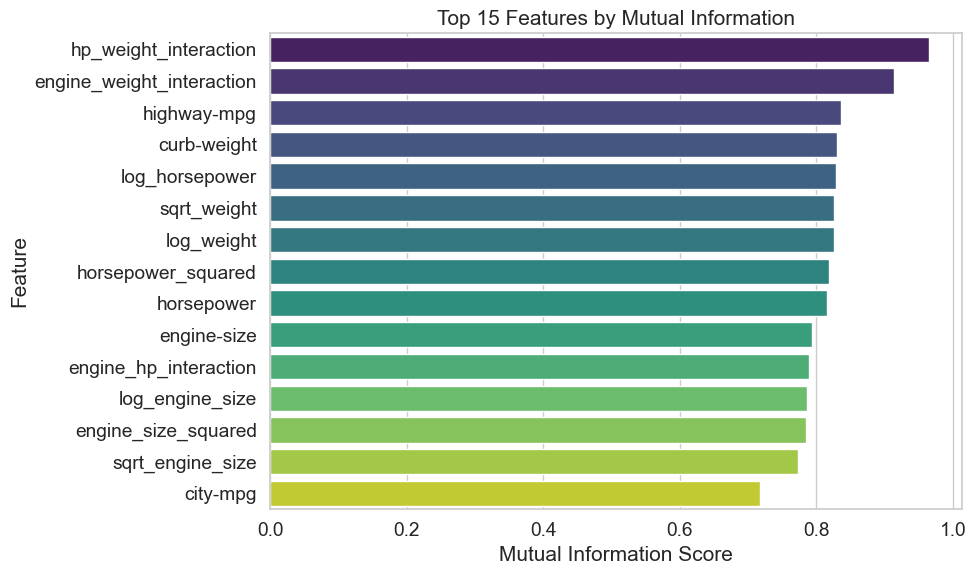

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    data=mi_df.head(15),
    x="MI_Score",
    y="Feature",
    palette="viridis"
)
plt.title("Top 15 Features by Mutual Information")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [53]:
top_k = 15
selected_features = mi_df.head(top_k)["Feature"].tolist()

X_mi_selected = X_scaled_df[selected_features]


## 3. Dimensionality Reduction by PCA  

PCA transforms our feature set into a new space of principal components, the linear combinations that capture the most variance.  
PCA helps us remove redundancy, accelerate model training and also visulize the structure of our data and it also helps us prevent overfitting if we have many features by inspecting its results.

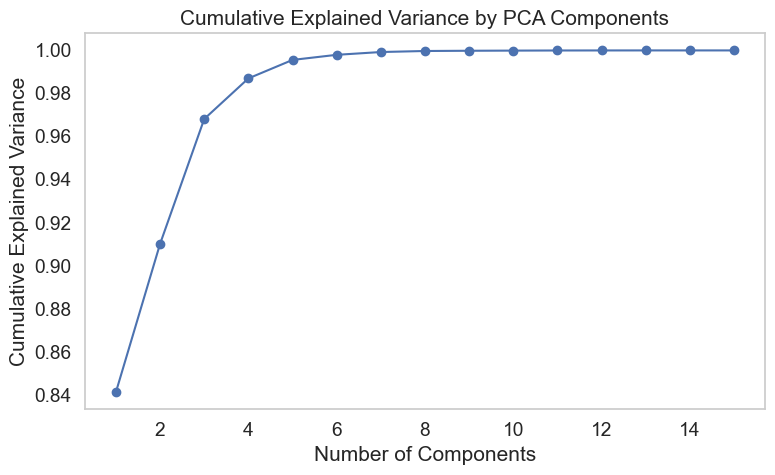

In [54]:
from sklearn.decomposition import PCA

# Fit PCA
pca = PCA()
pca.fit(X_mi_selected)

# Explained variance ratios for each component
explained_variance = pca.explained_variance_ratio_

import numpy as np

# Cumulative variance explained by first N components
cumulative_variance = np.cumsum(explained_variance)

# Display cumulative variance
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.tight_layout()
plt.show()


In [55]:
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components to explain 95% variance: {n_components}")


Number of components to explain 95% variance: 3


From the results above we can see that PC1 alone captures most of the structure of the dataset with around 84% of variance.  
PC1 + PC2 already captures around 91% and PC1+PC2+PC3 captures around 97%.  
So what we did was reducing 15 features to 3 components while keeping almost all information which is excellent.   
To ensure the PCA did not overfit the specific dataset, I used a Scree Plot to identify the ‘elbow,’ ensuring we only kept components with significant signal

In [56]:
# Now fit and transform with chosen n_components
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_mi_selected)

# Convert to DataFrame for convenience
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)])


In [57]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_mi_selected.columns,
    columns=[f'PC{i+1}' for i in range(n_components)]
)
loadings.head()


,PC1,PC2,PC3
hp_weight_interaction,0.274426,-0.020916,0.183560
engine_weight_interaction,0.268203,0.246389,-0.135931
highway-mpg,-0.234786,0.469268,0.105468
curb-weight,0.259666,-0.060343,-0.363667
log_horsepower,0.258710,-0.248991,0.260923


From the table above we can suggest that PC1 represents vehicle power/size and the important contributers are hp related features, weight related features and engine-weight interactions.  
The strongest feature in PC2 is highway MPG that suggests that PC2 is for the fuel efficieny dimentsion.  
PC3 constrasts heavy vehicles and powerful vehicles which can be interpreted as weight vs power balance.

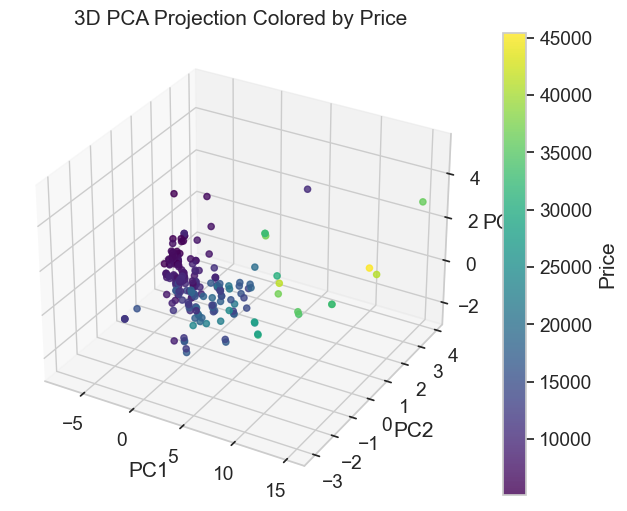

In [58]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca_df["PC1"],
    X_pca_df["PC2"],
    X_pca_df["PC3"],
    c=y,
    cmap="viridis",
    alpha=0.8
)



ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Projection Colored by Price")

fig.colorbar(scatter, label="Price")

plt.show()


Principal Component Analysis was visualized using a three‑dimensional scatter plot of the first three principal components. The points were colored according to vehicle price to observe how price relates to the reduced feature space. The visualization shows that vehicles with higher prices tend to appear at higher values of the first principal component. This indicates that PC1 captures characteristics associated with vehicle performance and size, such as horsepower and curb weight. Meanwhile, PC2 and PC3 introduce additional variation related to fuel efficiency and weight‑power balance. The clustering pattern suggests that most vehicles share similar specifications, while high‑performance vehicles appear as outliers in the PCA space.

## 4. Answer to the Final Question


Q: When is feature engineering a nice-to-have option and when is it a must-have?   

### Nice-to-Have  

Based on the experience I have gathered exploring this dataset I can say that if the dataset aleady contains well-designed variables that directly relate to the target, feature engineering may provide only marginal gains as a linear or tree-based model can already perform well with minimal transformation.   
Also some models can discover complex relationships without manual feature creation like neural networks or random forest. Feature engineering can help in these models but is not strictly required.  

### Must-Have

When the raw data doesn't represent the true relationship and the important relationships are implicit, the model can't simply learn them without feature engineering being done. Also when we are using linear or distance-based models such as linear regression, logistic regression, K-NN and Linear SVM and the dataset is not that well-designed feature engineering will come in handy.  
Also when strong non-liner relationships exist applying log, sqrt,... are often required.  



In general we can say that domain knowledge plays a crucial role here as raw data rarely reflects the real decision logic and if we lack domain knowledge, feature engineering probably becomes a must-have for us.